### Autors

Ziyi Hong - *2694933*

Danylo Tulainov - *5070969*

# Laborarbeit - Teil 2

## Ausgangssituation

Sie arbeiten im Data-Science-Team eines Unternehmens mit internem IT-Support.

Die Support-Leitung möchte eingehende Tickets automatisch danach einstufen, ob sie niedrige oder hohe Priorität haben. Ziel ist es, kritische Tickets schneller zu erkennen und zeitnah zu bearbeiten.

Die Fachabteilung stellt dabei zwei Anforderungen:

1. Das Verfahren soll einfach und nachvollziehbar sein.
2. Es soll möglich sein, für beide Klassen (niedrige Priorität/hohe Priorität) die wichtigsten Signalwörter anzugeben, also Wörter, die eher für hohe bzw. niedrige Priorität sprechen.

Außerdem steht nur ein relativ kleiner Datensatz zur Verfügung. Die Support-Leitung bevorzugt daher ein Verfahren, das auch bei begrenzter Datenmenge stabil einsetzbar ist.

## Datensatz

Sie erhalten den Datensatz `support_tickets_synthetisch_200.csv`.
Die Datei enthält die folgenden Spalten:

- `ticket_id`: eindeutige Ticket-ID
- `subject`: Betreff des Tickets
- `message`: eigentliche Ticketbeschreibung
- `priority`: Zielvariable mit den Klassen `hoch` und `niedrig`

## Aufgabe

**Ihre Aufgabe ist es auf Basis dieser Anforderungen eine Lösung für das Support-Team zu entwickeln.**

## Hinweise

Die Aufgabenstellung ist bewusst offen gehalten. Berücksichtigen Sie bei der Bearbeitung der Aufgabe die folgenden Hinweise:
* Dokumentieren Sie Ihr Vorgehen strukturiert und nachvollziehbar.
* Begründen Sie Ihre Vorgehensweise und Entscheidungen.
* Interpretieren Sie Ergebnisse.
* Erstellen Sie, wo möglich und sinnvoll, Plots.
* **Nutzen Sie nur Methoden, Konzepte und Begründungen, die in der Vorlesung behandelt wurden. Falls dies nicht möglich ist, begründen Sie warum.**
* Identifizieren Sie Schwachstellen/Limitationen Ihrer Arbeit und erläutern Sie diese auf Basis der Vorlesungsinhalte.

Berücksichtigen Sie die folgenden Hinweise für die Abgabe:
* Arbeiten Sie in 2er-Gruppen und geben Sie je Gruppe ein Notebook ab.
* Nennen Sie im abgegebenen Notebook die Gruppenmitglieder.
* **Für die Verwendung von KI berücksichtigen Sie die Hinweise von Herrn Prof. Hänisch.**
* Die erste Abgabe muss am Dienstag, den 17.03., zwischen 15:30 und 16:15 Uhr per Moodle erfolgen.
* Die endgültige Abgabe muss bis Dienstag, den 24.03., um 23:59 Uhr per Moodle erfolgen.
* Gewertet wird die endgültige Abgabe. Wenn Sie zwischen erster und endgültiger Abgabe Änderungen vornehmen, müssen Sie diese begründen.

## Business Understanding



## Data understanding

According to **CRISP-DM** the next step is *Data Understanding*.

At this stage the following steps are taken:
- Load of dataset
- Combine text features into one
- Store the target feature to `y` and training features to `X`
- Feature engineering:
    - Find the unique categories per target feature
    - Outline top features

#### Import packages

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df = pd.read_csv('support-dataset.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ticket_id  200 non-null    str  
 1   subject    200 non-null    str  
 2   message    200 non-null    str  
 3   priority   200 non-null    str  
dtypes: str(4)
memory usage: 6.4 KB


In [4]:
df.head()

,ticket_id,subject,message,priority
0,TKT-0039,Sicherheitsvorfall in Dateiserver,Es besteht der Verdacht auf einen Sicherheitsv...,niedrig
1,TKT-0134,Später umsetzen: Export nach Excel in SAP,Die Anpassung Export nach Excel in SAP wäre hi...,hoch
2,TKT-0070,Verdacht auf Datenverlust in E-Mail,In E-Mail fehlen seit 45 Minuten Datensätze. E...,hoch
3,TKT-0192,Wunsch: Dark Mode in Citrix,"Für Produktion besteht der Wunsch, in Citrix D...",niedrig
4,TKT-0018,Produktionsstillstand wegen Problemen mit Intr...,Durch Probleme mit Intranet besteht Produktion...,hoch


#### Define target and training variables

It was decided to combine features `subject` and `message` to maximize context. They are stored in `X`.

In [12]:
y = df['priority']

df['text'] = df['subject'] + ' ' + df['message']
X = df['text']

X.shape

(200,)

In [13]:
y.shape

(200,)

## Data Preparation

The next stage is  *Data Preparation*.

This stage combines these steps:
- Train-test-split
- Use bag of words encoding of `X`

In [2]:
# Combine subject and message to maximize the text context available for the model
df['text'] = df['subject'] + " " + df['message']

# Define features (X) and target (y)
X = df['text']
y = df['priority']

# Split the dataset into training and testing sets (80/20 split) to evaluate generalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize CountVectorizer (Bag of Words) to convert text into token counts
# This ignores word order but is highly effective for identifying isolated signal words
vectorizer = CountVectorizer(lowercase=True)

# Fit on training data and transform both sets
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## Modeling

In [3]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the Naive Bayes model
# Laplace smoothing (alpha=1.0) is strictly required to prevent zero probabilities for words in the test set that were unseen in the training set
nb_model = MultinomialNB(alpha=1.0)

# Train the model using the vectorized training data
nb_model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Evaluation

Classification Report:

              precision    recall  f1-score   support

        hoch       1.00      1.00      1.00        19
     niedrig       1.00      1.00      1.00        21

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Top Signal Words for Priority: HOCH


,word,score
210,seit,3.507834
159,mehr,3.448994
262,wodurch,3.319782
56,blockiert,3.284691
147,können,3.043529
172,möglich,2.948218
270,zugriff,2.896925
66,datenverlust,2.896925
7,aktuell,2.842858
244,verhindert,2.785700



Top Signal Words for Priority: NIEDRIG


,word,score
61,das,-4.125051
230,thema,-3.266390
175,nachrangig,-3.266390
236,um,-3.225568
141,komfort,-3.092036
181,nur,-2.991953
186,ohne,-2.991953
16,anpassung,-2.937886
183,nutzung,-2.880727
188,optimierung,-2.880727


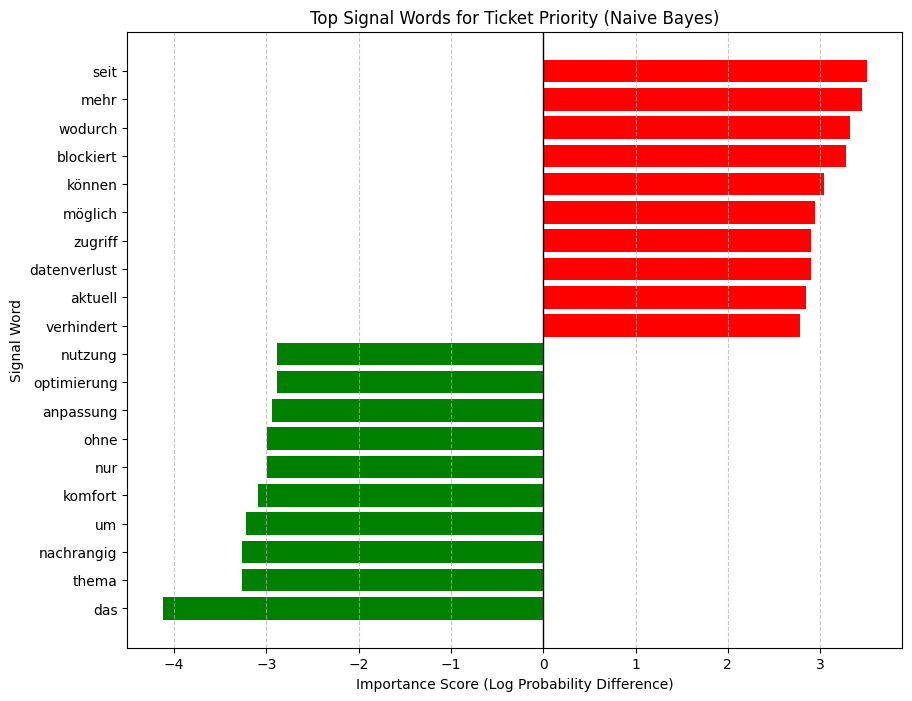

In [4]:
# 5. Evaluation
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# Generate predictions on the test set
y_pred = nb_model.predict(X_test_vec)

# Output standard classification metrics (Precision, Recall, F1-Score)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# --- Signal Word Extraction ---
feature_names = vectorizer.get_feature_names_out()
class_labels = nb_model.classes_.tolist()
idx_hoch = class_labels.index('hoch')
idx_niedrig = class_labels.index('niedrig')

# Extract the log probabilities calculated by the Naive Bayes model
log_prob_hoch = nb_model.feature_log_prob_[idx_hoch]
log_prob_niedrig = nb_model.feature_log_prob_[idx_niedrig]

# Calculate the difference to find the strongest predictors for each class
importance_score = log_prob_hoch - log_prob_niedrig

signal_words_df = pd.DataFrame({
    'word': feature_names,
    'score': importance_score
})

# Isolate top 10 signal words for both classes
top_words_hoch = signal_words_df.sort_values(by='score', ascending=False).head(10)
top_words_niedrig = signal_words_df.sort_values(by='score', ascending=True).head(10)

print("Top Signal Words for Priority: HOCH")
display(top_words_hoch)
print("\nTop Signal Words for Priority: NIEDRIG")
display(top_words_niedrig)

# --- Visualization ---
plot_df = pd.concat([top_words_hoch, top_words_niedrig]).sort_values(by='score')

plt.figure(figsize=(10, 8))
colors = ['green' if score < 0 else 'red' for score in plot_df['score']]
plt.barh(plot_df['word'], plot_df['score'], color=colors)
plt.title('Top Signal Words for Ticket Priority (Naive Bayes)')
plt.xlabel('Importance Score (Log Probability Difference)')
plt.ylabel('Signal Word')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Limitations (Based on Lecture Content):**
The primary limitation of this Naive Bayes approach is the assumption of conditional independence. The model evaluates the probability of each word independently and ignores context, syntax, and word order. For example, the phrase "kein Notfall" (not an emergency) might be misclassified if "Notfall" is heavily weighted as a high-priority signal word, because the model does not understand the negation.